In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("../data/raw/orders.csv")

print("Orders dataset loaded successfully!")
print("Shape:", orders.shape)

orders.head()

Orders dataset loaded successfully!
Shape: (60000, 9)


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_percent,payment_method,order_status
0,O100000,C101341,P1280,2025-06-28,2,6428.58,10,UPI,Delivered
1,O100001,C100981,P1252,2025-07-30,4,1455.88,0,UPI,Delivered
2,O100002,C109509,P1371,2025-06-29,4,3225.49,10,Credit Card,Delivered
3,O100003,C101497,P1421,2025-03-30,2,3737.93,10,UPI,Delivered
4,O100004,C101120,P1302,2025-09-13,4,3921.72,20,Debit Card,Delivered


In [2]:
print(orders.columns.tolist())

orders["order_date"] = pd.to_datetime(orders["order_date"])

print("Date converted successfully!")

['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount_percent', 'payment_method', 'order_status']
Date converted successfully!


In [3]:
orders["revenue"] = (
    orders["quantity"] *
    orders["unit_price"] *
    (1 - orders["discount_percent"] / 100)
)

daily_revenue = (
    orders.groupby("order_date")["revenue"]
    .sum()
    .reset_index()
)

daily_revenue.head()

,order_date,revenue
0,2025-01-01,801440.7595
1,2025-01-02,832066.0250
2,2025-01-03,978277.2155
3,2025-01-04,737331.4955
4,2025-01-05,845759.8775


In [4]:
# Create month column
orders["month"] = orders["order_date"].dt.to_period("M")

# Calculate monthly revenue
monthly_revenue = (
    orders.groupby("month")["revenue"]
    .sum()
    .reset_index()
)

# Convert month back to timestamp
monthly_revenue["month"] = monthly_revenue["month"].astype(str)

print("MONTHLY REVENUE ANALYSIS")
print("=" * 50)

monthly_revenue

MONTHLY REVENUE ANALYSIS


,month,revenue
0,2025-01,2.650921e+07
1,2025-02,2.404099e+07
2,2025-03,2.604751e+07
3,2025-04,2.632767e+07
4,2025-05,2.717935e+07
5,2025-06,2.619861e+07
6,2025-07,2.667107e+07
7,2025-08,2.600792e+07
8,2025-09,2.593578e+07
9,2025-10,2.619482e+07


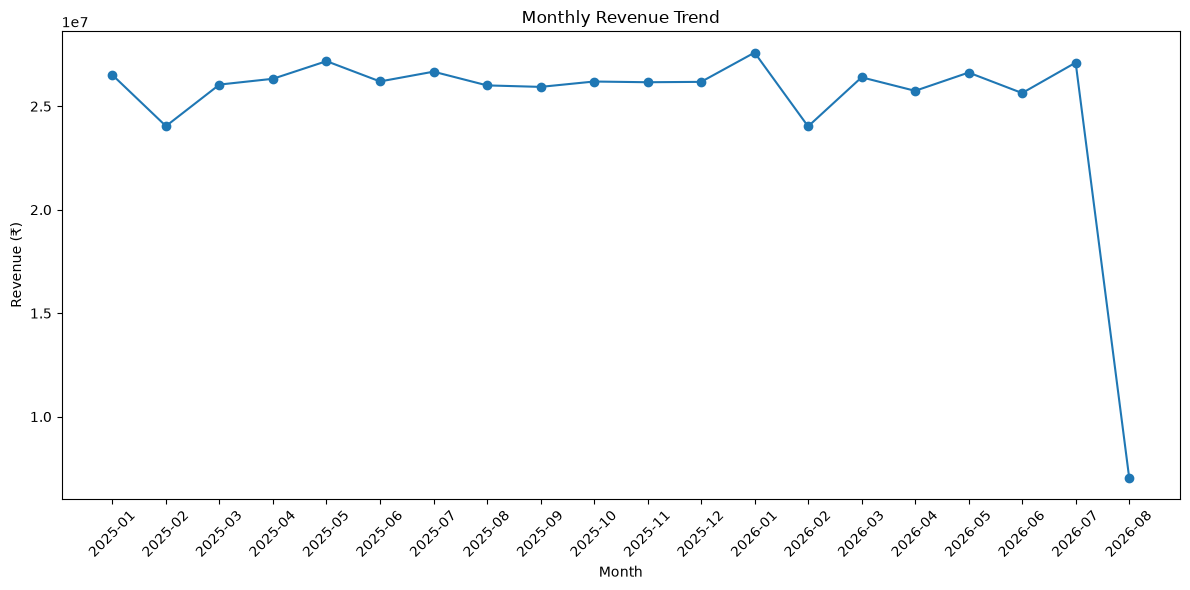

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# Remove incomplete last month for accurate forecasting

monthly_revenue_clean = monthly_revenue.iloc[:-1].copy()

print("Monthly Revenue Data for Forecasting")
print("=" * 50)

monthly_revenue_clean

Monthly Revenue Data for Forecasting


,month,revenue
0,2025-01,2.650921e+07
1,2025-02,2.404099e+07
2,2025-03,2.604751e+07
3,2025-04,2.632767e+07
4,2025-05,2.717935e+07
5,2025-06,2.619861e+07
6,2025-07,2.667107e+07
7,2025-08,2.600792e+07
8,2025-09,2.593578e+07
9,2025-10,2.619482e+07


In [7]:
# Create numerical time index

monthly_revenue_clean["month_index"] = range(
    1,
    len(monthly_revenue_clean) + 1
)

monthly_revenue_clean

,month,revenue,month_index
0,2025-01,2.650921e+07,1
1,2025-02,2.404099e+07,2
2,2025-03,2.604751e+07,3
3,2025-04,2.632767e+07,4
4,2025-05,2.717935e+07,5
5,2025-06,2.619861e+07,6
6,2025-07,2.667107e+07,7
7,2025-08,2.600792e+07,8
8,2025-09,2.593578e+07,9
9,2025-10,2.619482e+07,10


In [8]:
from sklearn.linear_model import LinearRegression

# Features and target
X = monthly_revenue_clean[["month_index"]]
y = monthly_revenue_clean["revenue"]

# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

print("Revenue Forecasting Model Trained Successfully!")

Revenue Forecasting Model Trained Successfully!


In [9]:
# Create future month indexes

future_months = pd.DataFrame({
    "month_index": range(
        len(monthly_revenue_clean) + 1,
        len(monthly_revenue_clean) + 7
    )
})

# Predict future revenue
future_months["forecasted_revenue"] = model.predict(
    future_months[["month_index"]]
)

future_months

,month_index,forecasted_revenue
0,20,2.630250e+07
1,21,2.631912e+07
2,22,2.633574e+07
3,23,2.635237e+07
4,24,2.636899e+07
5,25,2.638561e+07


In [10]:
# Create future month names

future_dates = pd.date_range(
    start="2026-08-01",
    periods=6,
    freq="MS"
)

future_months["month"] = future_dates.strftime("%Y-%m")

# Convert revenue to Crores for easier business understanding
future_months["forecasted_revenue_cr"] = (
    future_months["forecasted_revenue"] / 1e7
)

print("NEXT 6 MONTHS REVENUE FORECAST")
print("=" * 60)

future_months[
    [
        "month",
        "forecasted_revenue",
        "forecasted_revenue_cr"
    ]
]

NEXT 6 MONTHS REVENUE FORECAST


,month,forecasted_revenue,forecasted_revenue_cr
0,2026-08,2.630250e+07,2.630250
1,2026-09,2.631912e+07,2.631912
2,2026-10,2.633574e+07,2.633574
3,2026-11,2.635237e+07,2.635237
4,2026-12,2.636899e+07,2.636899
5,2027-01,2.638561e+07,2.638561


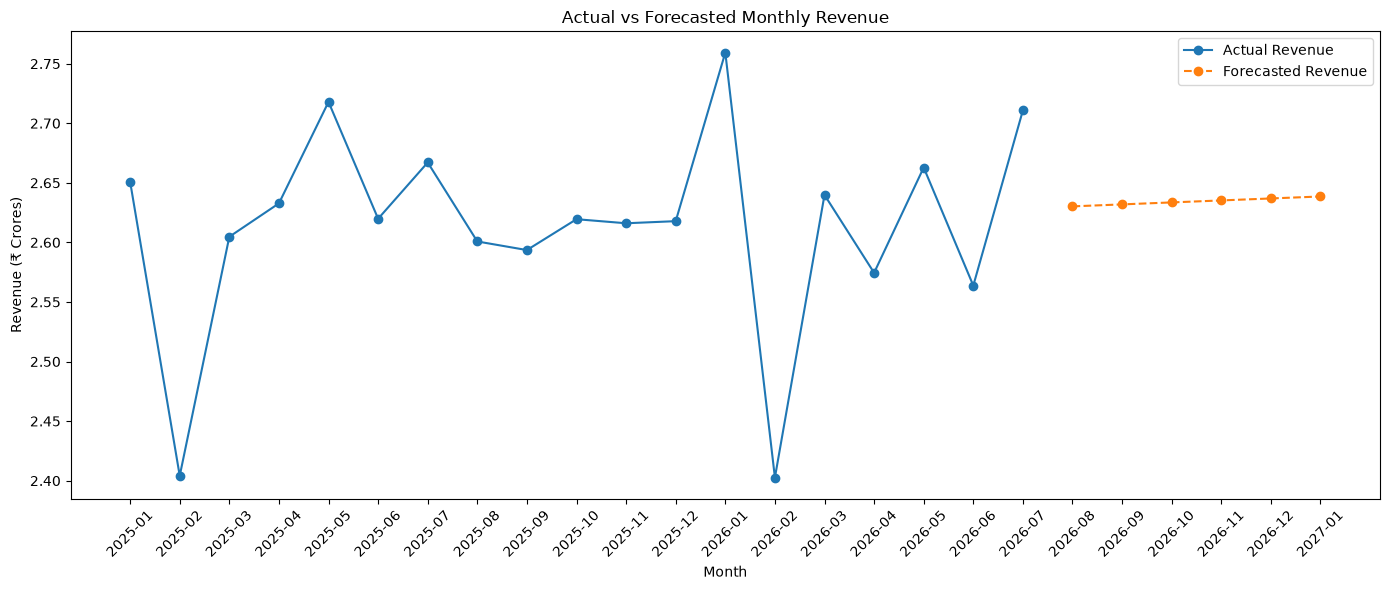

In [11]:
plt.figure(figsize=(14, 6))

# Actual revenue
plt.plot(
    monthly_revenue_clean["month"],
    monthly_revenue_clean["revenue"] / 1e7,
    marker="o",
    label="Actual Revenue"
)

# Forecasted revenue
plt.plot(
    future_months["month"],
    future_months["forecasted_revenue"] / 1e7,
    marker="o",
    linestyle="--",
    label="Forecasted Revenue"
)

plt.title("Actual vs Forecasted Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (₹ Crores)")
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()

plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict historical revenue
historical_predictions = model.predict(X)

# Calculate model metrics
mae = mean_absolute_error(y, historical_predictions)
rmse = np.sqrt(
    mean_squared_error(y, historical_predictions)
)
r2 = r2_score(y, historical_predictions)

print("REVENUE FORECASTING MODEL PERFORMANCE")
print("=" * 55)

print(f"Mean Absolute Error (MAE): ₹{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

REVENUE FORECASTING MODEL PERFORMANCE
Mean Absolute Error (MAE): ₹583,250.22
Root Mean Squared Error (RMSE): ₹861,189.11
R² Score: 0.0111


In [13]:
first_forecast = future_months[
    "forecasted_revenue"
].iloc[0]

last_forecast = future_months[
    "forecasted_revenue"
].iloc[-1]

forecast_growth = (
    (last_forecast - first_forecast)
    / first_forecast
) * 100

print("REVENUE FORECAST SUMMARY")
print("=" * 55)

print(f"First Forecast Month: {future_months['month'].iloc[0]}")
print(f"First Forecast Revenue: ₹{first_forecast / 1e7:.2f} Crore")

print()

print(f"Last Forecast Month: {future_months['month'].iloc[-1]}")
print(f"Last Forecast Revenue: ₹{last_forecast / 1e7:.2f} Crore")

print()
print(f"Forecast Growth: {forecast_growth:.2f}%")

REVENUE FORECAST SUMMARY
First Forecast Month: 2026-08
First Forecast Revenue: ₹2.63 Crore

Last Forecast Month: 2027-01
Last Forecast Revenue: ₹2.64 Crore

Forecast Growth: 0.32%


In [14]:
total_forecast_revenue = future_months[
    "forecasted_revenue"
].sum()

average_forecast_revenue = future_months[
    "forecasted_revenue"
].mean()

print("6-MONTH REVENUE FORECAST")
print("=" * 55)

print(
    f"Total Forecasted Revenue: "
    f"₹{total_forecast_revenue / 1e7:.2f} Crore"
)

print(
    f"Average Monthly Forecast: "
    f"₹{average_forecast_revenue / 1e7:.2f} Crore"
)

6-MONTH REVENUE FORECAST
Total Forecasted Revenue: ₹15.81 Crore
Average Monthly Forecast: ₹2.63 Crore


# Final Revenue Forecasting Insights

## Model Performance
The Linear Regression model produced an R² score of 0.0111, indicating that historical monthly revenue does not follow a strong linear trend. Revenue fluctuations are influenced by factors beyond simple time progression.

## Revenue Forecast
The model forecasts monthly revenue between approximately ₹2.63 Crore and ₹2.64 Crore from August 2026 to January 2027.

## Growth Outlook
Forecasted revenue growth is approximately 0.32% over the six-month period. This indicates a relatively stable revenue outlook with no significant organic growth trend.

## Business Implication
If the company continues its current strategy, revenue is expected to remain stable rather than grow significantly. To achieve higher growth, the company should improve customer retention, optimize marketing investments, promote high-performing products, and reduce churn.

## Forecast Summary
The company is expected to generate approximately ₹15.81 Crore in total revenue over the next six months, with an average monthly revenue of approximately ₹2.63 Crore.